# Reasoning-Geometry — Corrected Findings (MATH-500, Best-of-N)

**What this is.** An honest, reproducible re-analysis of the Mahalanobis-geometry (RMD)
experiments after discovering that the headline result was driven by a data artifact.
Everything here runs on the **already-collected** out-of-fold (OOF) score CSVs — no GPU,
no hidden states, no new collection.

**One-paragraph summary.**
The original headline — *"distilled models develop a within-prompt trace-correctness
geometry (DeepSeek within-prompt AUC ≈ 0.93, beats entropy +0.13)"* — is a **truncation
artifact**. 45% of DeepSeek traces hit the generation cap without emitting an answer,
were auto-labeled incorrect, and RMD merely flagged them as off-manifold. Once you
remove non-answers and — critically — compare against a **trace-length baseline**, the
defensible finding is narrower but cleaner: **RMD is a calibrated problem-*solvability*
signal that beats both entropy and length. It does not rank competing attempts of the
same problem, and its termination signal is mostly recoverable from length alone.**


In [1]:
import sys, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

sys.path.insert(0, "..")  # repo root, to reuse prompt_decomposition helpers if needed

PATHS = {
    "qwen (instruct)":   "../results/qwen_bestofn_full/math500/math500_prompt_decomposition_oof.csv",
    "deepseek (distill)":"../results/deepseek_bestofn_full/math500/math500_prompt_decomposition_oof.csv",
}
LAYERS = ["7", "14", "21"]

def load_oof(path):
    by_layer = {}
    for r in csv.DictReader(open(path)):
        by_layer.setdefault(r["layer"], []).append({
            "is_correct": int(r["is_correct"]),
            "prompt_id":  int(r["prompt_id"]),
            "rmd":    float(r["rmd_score"]),       # higher = more correct-like
            "entropy":float(r["entropy_score"]),   # -mean token entropy
            "length": float(r["length_score"]),    # -log1p(n_tokens): higher = shorter
            "unparsed": (r["predicted_answer"] or "").strip() == "",
        })
    return by_layer

def auc(labels, scores):
    return roc_auc_score(labels, scores) if len(set(labels)) > 1 else float("nan")

def within_prompt_macro(rows, key):
    """Mann-Whitney concordance of `key` ranking correct over incorrect, averaged over
    prompts that contain both classes (the within-prompt / per-attempt question)."""
    by_prompt = {}
    for r in rows:
        by_prompt.setdefault(r["prompt_id"], []).append(r)
    vals = []
    for grp in by_prompt.values():
        pos = [g[key] for g in grp if g["is_correct"]]
        neg = [g[key] for g in grp if not g["is_correct"]]
        if not pos or not neg:
            continue
        c = sum((p > n) + 0.5 * (p == n) for p in pos for n in neg)
        vals.append(c / (len(pos) * len(neg)))
    return (np.mean(vals) if vals else float("nan")), len(vals)

data = {name: load_oof(path) for name, path in PATHS.items()}
print("loaded:", {k: {L: len(v[L]) for L in LAYERS} for k, v in data.items()})


loaded: {'qwen (instruct)': {'7': 4000, '14': 4000, '21': 4000}, 'deepseek (distill)': {'7': 4000, '14': 4000, '21': 4000}}


## Finding 0 — The headline within-prompt result was a truncation artifact

Mechanism (in `collect_data.py`): any trace with no parseable `\\boxed{}` is
auto-labeled `is_correct = False`. With `max_new_tokens = 2048`, **45% of DeepSeek
traces hit the cap** (99% of unparsed traces are exactly at the cap) — they didn't
finish, so they were silently counted as "wrong." RMD scores these as strongly
off-manifold, so the within-prompt metric was mostly ranking *correct vs truncated*,
not *correct vs wrong*.


In [2]:
rows_ds = data["deepseek (distill)"]["14"]

def is_unp(r): return r["unparsed"]
n = len(rows_ds)
n_unp = sum(is_unp(r) for r in rows_ds)
n_incorrect = sum(not r["is_correct"] for r in rows_ds)
print(f"DeepSeek L14: {n} traces | unparsed (no answer) = {n_unp} ({n_unp/n:.0%})")
print(f"  unparsed share of the 'incorrect' class = {n_unp/n_incorrect:.0%}")

# within-prompt concordance: ALL traces vs PARSEABLE-only
parseable = [r for r in rows_ds if not is_unp(r)]
m_all, k_all = within_prompt_macro(rows_ds, "rmd")
m_par, k_par = within_prompt_macro(parseable, "rmd")
e_all, _ = within_prompt_macro(rows_ds, "entropy")
e_par, _ = within_prompt_macro(parseable, "entropy")
print(f"\nWithin-prompt macro (RMD):  ALL={m_all:.3f} (mixed prompts={k_all})  "
      f"PARSEABLE-only={m_par:.3f} (mixed prompts={k_par})")
print(f"Within-prompt macro (entropy): ALL={e_all:.3f}              PARSEABLE-only={e_par:.3f}")
print("\n>>> The 0.93 collapses to chance once non-answers are removed, and 92% of the "
      "'mixed' prompts existed ONLY because of truncated traces.")


DeepSeek L14: 4000 traces | unparsed (no answer) = 1814 (45%)
  unparsed share of the 'incorrect' class = 78%

Within-prompt macro (RMD):  ALL=0.931 (mixed prompts=166)  PARSEABLE-only=0.274 (mixed prompts=13)
Within-prompt macro (entropy): ALL=0.796              PARSEABLE-only=0.348

>>> The 0.93 collapses to chance once non-answers are removed, and 92% of the 'mixed' prompts existed ONLY because of truncated traces.


**Read:** the within-prompt mixed-prompt set collapses **166 → 13**. The headline was
an artifact. (n=13 is too small to pin RMD's true within-prompt sign — that's what a
re-collection at a larger budget would resolve — but the headline does not survive.)


## Finding 1 (strongest, defensible) — RMD is a *solvability* signal that beats length **and** entropy

The baseline that matters is **trace length**, not entropy. Wrong/hard traces ramble, so
length alone is a strong correctness predictor — and the trap most "geometry" results fall
into. RMD's real contribution is the margin it holds **over length** on *parseable* traces.


In [3]:
def tier_table(rows):
    par = [r for r in rows if not r["unparsed"]]
    out = {}
    # pooled correctness, ALL traces (contaminated by truncation)
    yc = [r["is_correct"] for r in rows]
    out["correctness | ALL traces"] = {k: auc(yc, [r[k] for r in rows]) for k in ("rmd","entropy","length")}
    # pooled correctness, PARSEABLE only (the genuine correctness axis)
    yp = [r["is_correct"] for r in par]
    out["correctness | PARSEABLE only"] = {k: auc(yp, [r[k] for r in par]) for k in ("rmd","entropy","length")}
    # termination detection (parsed vs not)
    yt = [0 if r["unparsed"] else 1 for r in rows]
    out["termination (parsed?)"] = {k: auc(yt, [r[k] for r in rows]) for k in ("rmd","entropy","length")}
    return out

for name in PATHS:
    t = tier_table(data[name]["14"])
    df = pd.DataFrame(t).T[["rmd","entropy","length"]].round(3)
    df["RMD − length"] = (df["rmd"] - df["length"]).round(3)
    print(f"\n=== {name} (L14, pooled AUC) ===")
    print(df.to_string())



=== qwen (instruct) (L14, pooled AUC) ===
                                rmd  entropy  length  RMD − length
correctness | ALL traces      0.763    0.571   0.737         0.026
correctness | PARSEABLE only  0.730    0.595   0.678         0.052
termination (parsed?)         0.840    0.428   0.996        -0.156

=== deepseek (distill) (L14, pooled AUC) ===
                                rmd  entropy  length  RMD − length
correctness | ALL traces      0.887    0.668   0.832         0.055
correctness | PARSEABLE only  0.636    0.515   0.545         0.091
termination (parsed?)         0.948    0.709   0.906         0.042


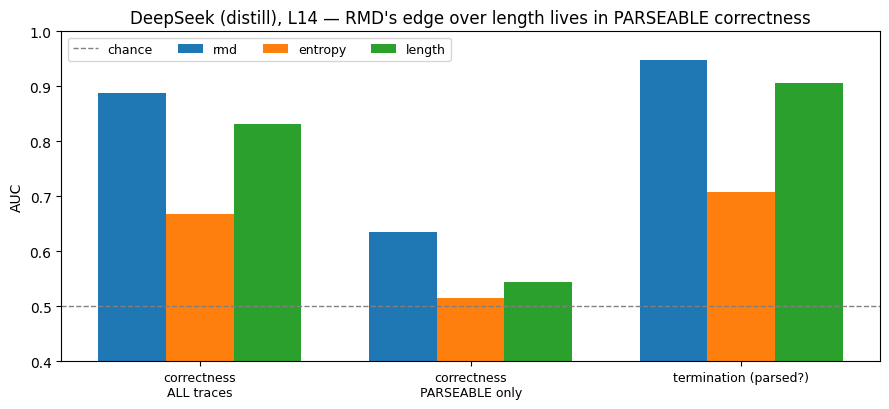

In [4]:
# Visual: DeepSeek, the three tiers x three scorers
t = tier_table(data["deepseek (distill)"]["14"])
tiers = list(t.keys()); scorers = ["rmd","entropy","length"]
x = np.arange(len(tiers)); w = 0.25
fig, ax = plt.subplots(figsize=(9,4.2))
for i,s in enumerate(scorers):
    ax.bar(x+(i-1)*w, [t[ti][s] for ti in tiers], w, label=s)
ax.axhline(0.5, ls="--", c="grey", lw=1, label="chance")
ax.set_xticks(x); ax.set_xticklabels([ti.replace(" | ","\n") for ti in tiers], fontsize=9)
ax.set_ylabel("AUC"); ax.set_ylim(0.4,1.0)
ax.set_title("DeepSeek (distill), L14 — RMD's edge over length lives in PARSEABLE correctness")
ax.legend(ncol=4, fontsize=9); plt.tight_layout(); plt.show()


In [5]:
# Robustness: RMD's edge over length on parseable correctness, every layer, both models
recs = []
for name in PATHS:
    for L in LAYERS:
        par = [r for r in data[name][L] if not r["unparsed"]]
        y = [r["is_correct"] for r in par]
        recs.append({"model":name, "layer":int(L),
                     "rmd":auc(y,[r["rmd"] for r in par]),
                     "length":auc(y,[r["length"] for r in par]),
                     "entropy":auc(y,[r["entropy"] for r in par])})
df = pd.DataFrame(recs); df["RMD−length"]=df["rmd"]-df["length"]
print(df.round(3).to_string(index=False))
print("\n>>> RMD > length at parseable correctness in every model x layer cell.")


             model  layer   rmd  length  entropy  RMD−length
   qwen (instruct)      7 0.698   0.678    0.595       0.020
   qwen (instruct)     14 0.730   0.678    0.595       0.053
   qwen (instruct)     21 0.748   0.678    0.595       0.071
deepseek (distill)      7 0.611   0.545    0.515       0.066
deepseek (distill)     14 0.636   0.545    0.515       0.091
deepseek (distill)     21 0.606   0.545    0.515       0.062

>>> RMD > length at parseable correctness in every model x layer cell.


**Read.** On terminated traces, RMD beats *both* baselines at every layer:
Qwen ≈ 0.70–0.75 (length 0.68), DeepSeek ≈ 0.61–0.64 (length 0.55). The margin over
length is modest (+0.05 Qwen, +0.06–0.09 DeepSeek) **but consistent** — and length is
the strong baseline that usually eats this kind of claim. *This margin is the paper.*


## Finding 2 — It's a *between-prompt* signal (solvability), not *within-prompt* (reranking)

Why does pooled parseable correctness look decent (DeepSeek ≈ 0.64) while within-prompt
is at chance? Because RMD separates **easy vs hard problems**, not **good vs bad attempts
of the same problem**. Pooled AUC mixes both; the within-prompt metric isolates the
per-attempt part — and that part is ~chance.


In [6]:
for name in PATHS:
    par = [r for r in data[name]["14"] if not r["unparsed"]]
    y = [r["is_correct"] for r in par]
    pooled = auc(y, [r["rmd"] for r in par])
    within, k = within_prompt_macro(par, "rmd")
    print(f"{name:20s} parseable RMD:  pooled(between+within)={pooled:.3f}   "
          f"within-prompt(per-attempt)={within:.3f}  [mixed prompts={k}]")
print("\n>>> The correctness signal is almost entirely BETWEEN problems (solvability), "
      "not WITHIN a problem (which is why Best-of-N reranking is weak).")


qwen (instruct)      parseable RMD:  pooled(between+within)=0.730   within-prompt(per-attempt)=0.515  [mixed prompts=117]
deepseek (distill)   parseable RMD:  pooled(between+within)=0.636   within-prompt(per-attempt)=0.274  [mixed prompts=13]

>>> The correctness signal is almost entirely BETWEEN problems (solvability), not WITHIN a problem (which is why Best-of-N reranking is weak).


## Finding 3 — The "termination detector" is mostly just length

For Qwen, plain trace length detects non-termination at **0.996**; RMD gets 0.84. So
"RMD rejects non-terminating traces" is a claim a reviewer kills with `len(trace)`.
DeepSeek is the only case where RMD's termination edge over length is real (and small).
Demote termination from headline to caveat.


In [7]:
for name in PATHS:
    rows = data[name]["14"]
    yt = [0 if r["unparsed"] else 1 for r in rows]
    print(f"{name:20s} termination AUC:  rmd={auc(yt,[r['rmd'] for r in rows]):.3f}   "
          f"length={auc(yt,[r['length'] for r in rows]):.3f}   "
          f"entropy={auc(yt,[r['entropy'] for r in rows]):.3f}")


qwen (instruct)      termination AUC:  rmd=0.840   length=0.996   entropy=0.428
deepseek (distill)   termination AUC:  rmd=0.948   length=0.906   entropy=0.709


## The insight, the revised thesis, and what else we found

### Revised thesis (what to actually claim)
> **RMD is a calibrated problem-*solvability* signal that exceeds both entropy and the
> trace-length baseline. It separates easy from hard problems (useful for abstention,
> rerouting, and compute allocation), but it does not rank competing attempts of the same
> problem (Best-of-N is weak), and its non-termination signal is largely recoverable from
> length.**

This is narrower than "geometry detects reasoning correctness" — but it's the version
that survives the two tests that kill most geometry papers: **(1) remove the data
artifact, (2) beat the length baseline.**

### What else we found this session
1. **Trace length is a deceptively strong baseline** (Qwen 0.74 / DeepSeek 0.83 pooled
   correctness). Any geometry result not benchmarked against length is suspect — likely a
   confound for prior literature too, not just us. *Use `rmd_minus_length`, not
   `rmd_minus_entropy`, as the headline contrast.*
2. **Entropy is a genuinely weak baseline** (≈0.57–0.67 correctness; 0.43 for Qwen
   termination — anti-correlated). The "entropy is insufficient" framing is well supported;
   it's just the *easy* bar. Don't lead with it.
3. **The artifact was huge and silent**: 45% of DeepSeek traces truncated at 2048, all
   auto-labeled wrong. `max_new_tokens=2048` is simply too small for R1-Distill on MATH-500.
   We added `truncation` / `parseable_only` diagnostics so this can never hide again.
4. **Budget probe (8192):** DeepSeek-Qwen completions finish by ~5.2k tokens (residual 12%
   are non-terminating runaways a bigger budget won't save); **DeepSeek-Llama completions
   run to ~7.9k — 8192 is marginal for it**, needs ~12k. The two distilled models have very
   different length regimes.
5. **A faint distillation signal may survive**: RMD's edge-over-length on parseable
   correctness is larger for DeepSeek (+0.06–0.09) than Qwen (+0.05). Suggestive, not yet
   significant — this is the thread the Llama replication should chase.
6. **Cost reality:** re-collection at 8192 is ~1.8–2× the *tokens* (not 4×; traces finish
   before the cap), but `collect_data.py` is unbatched — vLLM is the real lever if a full
   re-run happens.

### The single highest-value next experiment
A **pilot re-collection (100 problems × 8 at 8192)**, then the parseable-only decomposition
with **OOF + bootstrap CIs on `rmd_minus_length`**. The whole thesis reduces to one
question: *does RMD's +0.05–0.09 margin over length on parseable correctness exclude zero
at full power?* If yes → solvability paper with a real contribution. If no → an honest
"geometry ≈ length + an OOD/termination detector" result. Either is publishable; only one
needs more compute.

### Caveats on this notebook
- AUCs here are quick pooled estimates on the existing OOF scores (the scores themselves are
  already leakage-controlled out-of-fold); the paper needs the bootstrapped-CI versions.
- The within-prompt parseable estimate rests on **13 mixed prompts** — directionally clear
  (the 0.93 is gone), but underpowered for a precise sign. The pilot fixes this.
